# Clasificación Supervisada con Random Forest
## Dataset: Video Game Sales (vgsales.csv)


1. Carga y exploración de datos
2. Limpieza y preprocesamiento
3. Ingeniería de características y variable objetivo
4. División entrenamiento / prueba
5. Escalado de características
6. Entrenamiento del modelo (Random Forest)
7. Evaluación: exactitud, precisión, recall, F1
8. Matriz de confusión
9. Ajuste de hiperparámetros
10. Predicción individual

In [ ]:
%pip install numpy pandas matplotlib scikit-learn

In [ ]:
# Importación de bibliotecas de análisis, visualización y aprendizaje automático.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Módulos de scikit-learn para el flujo completo de ML supervisado.
from sklearn.model_selection  import train_test_split
from sklearn.preprocessing    import StandardScaler, LabelEncoder
from sklearn.ensemble         import RandomForestClassifier
from sklearn.metrics          import (accuracy_score, precision_score,
                                      recall_score, f1_score,
                                      confusion_matrix, classification_report)

plt.style.use("seaborn-v0_8-whitegrid")
SEED = 42  # semilla global para reproducibilidad de todos los experimentos

---
## 1. Carga y Exploración Inicial



In [ ]:
# Carga del dataset desde archivo CSV local.
df = pd.read_csv("vgsales.csv")

print(f"Dimensiones: {df.shape[0]} filas × {df.shape[1]} columnas")
df.head()

Dimensiones: 16598 filas × 11 columnas


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [ ]:
# Resumen de tipos de dato y valores no nulos por columna.
# Detectar columnas con nulos es el primer paso de limpieza.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  object 
 2   Platform      16598 non-null  object 
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  object 
 5   Publisher     16540 non-null  object 
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB


In [ ]:
# Estadísticas descriptivas de las columnas numéricas.
# Útil para detectar rangos anómalos, asimetrías y posibles outliers.
df.describe()

,Rank,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16598.000000,16327.000000,16598.000000,16598.000000,16598.000000,16598.000000,16598.000000
mean,8300.605254,2006.406443,0.264667,0.146652,0.077782,0.048063,0.537441
std,4791.853933,5.828981,0.816683,0.505351,0.309291,0.188588,1.555028
min,1.000000,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000
25%,4151.250000,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000
50%,8300.500000,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000
75%,12449.750000,2010.000000,0.240000,0.110000,0.040000,0.040000,0.470000
max,16600.000000,2020.000000,41.490000,29.020000,10.220000,10.570000,82.740000


---
## 2. Limpieza y Preprocesamiento



In [ ]:
# Conteo de valores nulos por columna antes de cualquier tratamiento.
print("Valores nulos por columna:")
print(df.isnull().sum())

Valores nulos por columna:
Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64


In [ ]:
# Eliminación de filas con nulos en columnas imprescindibles para el modelo.
# `dropna` con `subset` solo elimina filas donde ESAS columnas son nulas.
df = df.dropna(subset=["Year", "Publisher"])
print(f"Registros tras dropna: {len(df)}")

Registros tras dropna: 16291


In [ ]:
# Conversión de tipos: 'Year' llega como float por los nulos originales.
# Una vez eliminados los nulos, se convierte a entero para operar con él.
df["Year"] = df["Year"].astype(int)

In [ ]:
# Eliminación de filas duplicadas para evitar que el modelo aprenda
# patrones artificialmente reforzados por registros repetidos.
n_dup = df.duplicated().sum()
print(f"Duplicados eliminados: {n_dup}")
df = df.drop_duplicates()

Duplicados eliminados: 0


In [ ]:
# Detección y exclusión de outliers extremos mediante percentiles.
# Se conservan solo registros por debajo del percentil 99 en ventas globales.
p99 = df["Global_Sales"].quantile(0.99)
df  = df[df["Global_Sales"] <= p99].copy()
print(f"Registros tras filtro de outliers (p99 = {p99:.2f} M): {len(df)}")

Registros tras filtro de outliers (p99 = 5.47 M): 16128


In [ ]:
# Verificación final: el dataset limpio no debe tener nulos en ninguna columna usada.
assert df[["Year", "Publisher", "Genre", "Platform",
           "NA_Sales", "EU_Sales", "JP_Sales", "Global_Sales"]].isnull().sum().sum() == 0
print("Verificación superada: ningún nulo en las columnas de trabajo.")

Verificación superada: ningún nulo en las columnas de trabajo.


---
## 3. Ingeniería de Características y Variable Objetivo

La **variable objetivo** (target) es la columna que el modelo aprenderá a predecir.


Aquí se define `es_superventas`: 1 si las ventas globales superan la mediana,
0 en caso contrario. Esto crea un problema de clasificación binaria balanceado.

In [ ]:
# Creación de la variable objetivo binaria a partir de un umbral de ventas.
# El uso de la mediana garantiza aproximadamente 50% de ejemplos por clase.
mediana_ventas  = df["Global_Sales"].median()
df["es_superventas"] = (df["Global_Sales"] > mediana_ventas).astype(int)

print(f"Mediana de ventas globales: {mediana_ventas:.2f} M")
print(df["es_superventas"].value_counts())

Mediana de ventas globales: 0.17 M
es_superventas
0    8229
1    7899
Name: count, dtype: int64


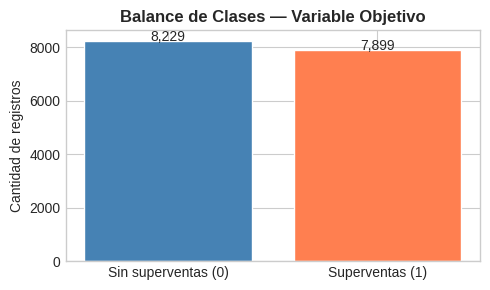

In [ ]:
# Visualización del balance de clases.
# Un dataset muy desbalanceado requeriría técnicas adicionales (SMOTE, class_weight).
conteo = df["es_superventas"].value_counts()
fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(["Sin superventas (0)", "Superventas (1)"], conteo.values,
       color=["steelblue", "coral"], edgecolor="white")
ax.set_title("Balance de Clases — Variable Objetivo", fontweight="bold")
ax.set_ylabel("Cantidad de registros")
for i, v in enumerate(conteo.values):
    ax.text(i, v + 20, f"{v:,}", ha="center")
plt.tight_layout()
plt.show()

In [ ]:
# Codificación de variables categóricas con LabelEncoder.
# Los algoritmos de ML requieren entradas numéricas; las etiquetas de texto
# deben transformarse antes del entrenamiento.
le_genre    = LabelEncoder()
le_platform = LabelEncoder()

df["Genre_enc"]    = le_genre.fit_transform(df["Genre"])
df["Platform_enc"] = le_platform.fit_transform(df["Platform"])

# Mapeo de referencia: permite interpretar las predicciones.
print("Géneros codificados:")
for cls, code in zip(le_genre.classes_, range(len(le_genre.classes_))):
    print(f"  {code:2d} → {cls}")

Géneros codificados:
   0 → Action
   1 → Adventure
   2 → Fighting
   3 → Misc
   4 → Platform
   5 → Puzzle
   6 → Racing
   7 → Role-Playing
   8 → Shooter
   9 → Simulation
  10 → Sports
  11 → Strategy


In [ ]:
# Selección de características (features) que usará el modelo.
FEATURES = ["NA_Sales", "EU_Sales", "JP_Sales", "Year", "Genre_enc", "Platform_enc"]
TARGET   = "es_superventas"

X = df[FEATURES].values  # matriz de features (numpy array)
y = df[TARGET].values     # vector objetivo

---
## 4. División Entrenamiento / Prueba

El dataset se divide en dos subconjuntos:
- **Entrenamiento (train)**: el modelo aprende los patrones a partir de estos datos.
- **Prueba (test)**: datos nunca vistos por el modelo, usados para medir el rendimiento real.

La proporción 80/20 es la más habitual


In [ ]:
# División estratificada: `stratify=y` mantiene la proporción de clases en ambos
# subconjuntos, evitando particiones accidentalmente desbalanceadas.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=SEED,
    stratify=y,
)
print(f"Entrenamiento : {X_train.shape[0]} muestras")
print(f"Prueba        : {X_test.shape[0]} muestras")
print(f"Proporción 0/1 en train: {np.bincount(y_train)}")
print(f"Proporción 0/1 en test : {np.bincount(y_test)}")

Entrenamiento : 12902 muestras
Prueba        : 3226 muestras
Proporción 0/1 en train: [6583 6319]
Proporción 0/1 en test : [1646 1580]


---
## 5. Escalado de Características

`StandardScaler` transforma cada columna para que tenga media 0 y desviación
estándar 1. Esto evita que variables con rangos grandes
dominen sobre variables pequeñas .

**Regla importante**: el scaler se ajusta SOLO con datos de entrenamiento
(`fit_transform`) y luego se APLICA al conjunto de prueba (`transform`).
Ajustarlo con test contaminaría la evaluación (data leakage).

In [ ]:
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)  # ajusta y transforma con datos de entrenamiento
X_test  = scaler.transform(X_test)       # solo transforma con los parámetros ya ajustados

print("Media de cada feature tras escalar (debe ser ≈ 0):")
print(np.round(X_train.mean(axis=0), 3))
print("Desv. std de cada feature tras escalar (debe ser ≈ 1):")
print(np.round(X_train.std(axis=0), 3))

Media de cada feature tras escalar (debe ser ≈ 0):
[-0.  0.  0. -0.  0. -0.]
Desv. std de cada feature tras escalar (debe ser ≈ 1):
[1. 1. 1. 1. 1. 1.]


---
## 6. Entrenamiento del Modelo — Random Forest

**Random Forest** es un conjunto (ensemble) de árboles de decisión entrenados
sobre subconjuntos aleatorios de datos y características. La predicción final
es la votación mayoritaria de todos los árboles.



In [ ]:
# Instanciación del modelo con hiperparámetros iniciales.
modelo = RandomForestClassifier(
    n_estimators  = 100,   # cantidad de árboles en el bosque
    max_depth     = 10,    # profundidad máxima de cada árbol
    max_leaf_nodes= 50,    # número máximo de hojas por árbol
    random_state  = SEED,
    n_jobs        = -1,    # usa todos los núcleos disponibles
)

# Entrenamiento: el modelo ajusta sus parámetros internos a los datos de train.
modelo.fit(X_train, y_train)
print("Modelo entrenado correctamente.")
print(f"Árboles en el bosque: {len(modelo.estimators_)}")

Modelo entrenado correctamente.
Árboles en el bosque: 100


---
## 7. Evaluación del Modelo


| Métrica | Pregunta que responde |
|---|---|
| **Exactitud** | ¿Qué fracción de todas las predicciones son correctas? |
| **Precisión** | De los predichos como positivos, ¿cuántos lo son realmente? |
| **Recall** | De todos los positivos reales, ¿cuántos detectó el modelo? |
| **F1 Score** | Balance armónico entre Precisión y Recall |

In [ ]:
# Generación de predicciones sobre el conjunto de prueba.
y_pred = modelo.predict(X_test)

# Cálculo de las cuatro métricas estándar de clasificación binaria.
exactitud  = accuracy_score (y_test, y_pred)
precision  = precision_score(y_test, y_pred)
recall     = recall_score   (y_test, y_pred)
f1         = f1_score       (y_test, y_pred)

print("=" * 40)
print("   Métricas de Rendimiento del Modelo")
print("=" * 40)
print(f"  Exactitud  : {exactitud:.4f}  ({exactitud*100:.1f}%)")
print(f"  Precisión  : {precision:.4f}  ({precision*100:.1f}%)")
print(f"  Recall     : {recall:.4f}  ({recall*100:.1f}%)")
print(f"  F1 Score   : {f1:.4f}  ({f1*100:.1f}%)")

   Métricas de Rendimiento del Modelo
  Exactitud  : 0.9851  (98.5%)
  Precisión  : 0.9923  (99.2%)
  Recall     : 0.9772  (97.7%)
  F1 Score   : 0.9847  (98.5%)


In [ ]:
# Reporte completo de clasificación por clase.
# Muestra soporte (cantidad de muestras reales) por cada clase.
print(classification_report(y_test, y_pred,
                             target_names=["Sin superventas", "Superventas"]))

                 precision    recall  f1-score   support

Sin superventas       0.98      0.99      0.99      1646
    Superventas       0.99      0.98      0.98      1580

       accuracy                           0.99      3226
      macro avg       0.99      0.98      0.99      3226
   weighted avg       0.99      0.99      0.99      3226



---
## 8. Matriz de Confusión

La matriz de confusión desglosa las predicciones en cuatro categorías:

|  | Pred: Negativo | Pred: Positivo |
|---|---|---|
| **Real: Negativo** | Verdadero Negativo (TN) | Falso Positivo (FP) |
| **Real: Positivo** | Falso Negativo (FN) | Verdadero Positivo (TP) |



TN=1634  FP=12  FN=36  TP=1544


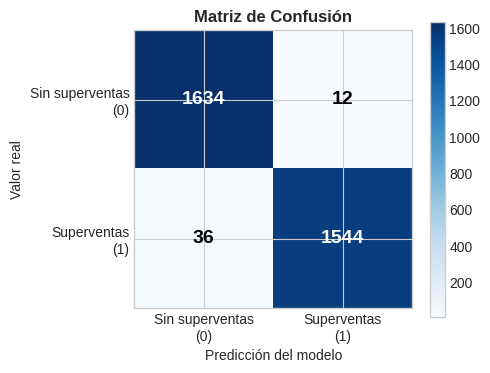

In [ ]:
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
print(f"TN={tn}  FP={fp}  FN={fn}  TP={tp}")

# Visualización de la matriz de confusión como mapa de calor.
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")
plt.colorbar(im, ax=ax)

etiquetas = ["Sin superventas\n(0)", "Superventas\n(1)"]
ax.set_xticks([0, 1]); ax.set_xticklabels(etiquetas)
ax.set_yticks([0, 1]); ax.set_yticklabels(etiquetas)
ax.set_xlabel("Predicción del modelo")
ax.set_ylabel("Valor real")
ax.set_title("Matriz de Confusión", fontweight="bold")

for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]),
                ha="center", va="center",
                fontsize=14, fontweight="bold",
                color="white" if cm[i, j] > cm.max() / 2 else "black")

plt.tight_layout()
plt.show()

---
## 9. Ajuste de Hiperparámetros


- `n_estimators`   → cantidad de árboles
- `max_depth`      → profundidad máxima de cada árbol
- `max_leaf_nodes` → número máximo de hojas por árbol

A continuación se evalúa el impacto de variar `n_estimators` manteniendo
los otros fijos, para ilustrar cómo una interfaz de ajuste afecta al modelo.

In [ ]:
# Barrido manual de hiperparámetros: evalúa el F1 para distintos valores
# de número de árboles y registra los resultados en una tabla.
resultados = []

for n_arboles in [10, 50, 100, 200, 300]:
    m = RandomForestClassifier(
        n_estimators  = n_arboles,
        max_depth     = 10,
        max_leaf_nodes= 50,
        random_state  = SEED,
        n_jobs        = -1,
    )
    m.fit(X_train, y_train)
    pred = m.predict(X_test)
    resultados.append({
        "n_estimators": n_arboles,
        "Exactitud"   : round(accuracy_score(y_test, pred), 4),
        "Precisión"   : round(precision_score(y_test, pred), 4),
        "Recall"      : round(recall_score(y_test, pred), 4),
        "F1 Score"    : round(f1_score(y_test, pred), 4),
    })

df_resultados = pd.DataFrame(resultados).set_index("n_estimators")
print(df_resultados)

              Exactitud  Precisión  Recall  F1 Score
n_estimators                                        
10               0.9839     0.9904  0.9766    0.9834
50               0.9861     0.9936  0.9778    0.9856
100              0.9851     0.9923  0.9772    0.9847
200              0.9854     0.9910  0.9791    0.9850
300              0.9854     0.9917  0.9785    0.9850


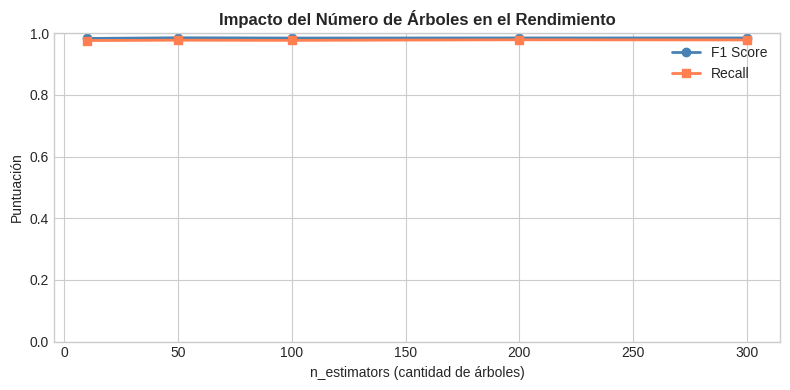

In [ ]:
# Gráfica de la evolución del F1 Score según el número de árboles.
# Permite identificar el punto de rendimiento óptimo sin costo computacional excesivo.
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(df_resultados.index, df_resultados["F1 Score"],
        marker="o", linewidth=2, color="steelblue", label="F1 Score")
ax.plot(df_resultados.index, df_resultados["Recall"],
        marker="s", linewidth=2, color="coral",     label="Recall")
ax.set_title("Impacto del Número de Árboles en el Rendimiento", fontweight="bold")
ax.set_xlabel("n_estimators (cantidad de árboles)")
ax.set_ylabel("Puntuación")
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

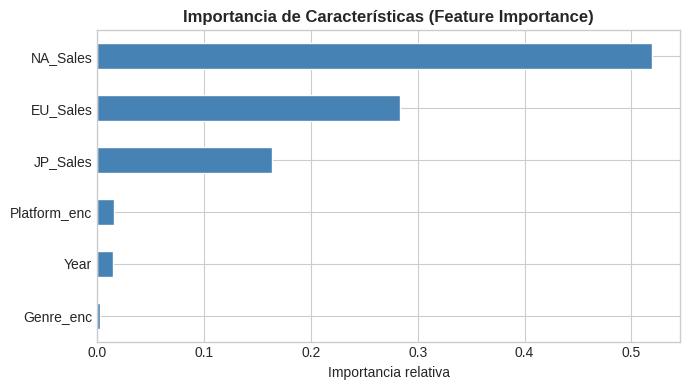

In [ ]:
# Importancia de características: indica cuánto aporta cada feature a las decisiones.
importancias = pd.Series(modelo.feature_importances_, index=FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(7, 4))
importancias.plot(kind="barh", ax=ax, color="steelblue", edgecolor="white")
ax.set_title("Importancia de Características (Feature Importance)", fontweight="bold")
ax.set_xlabel("Importancia relativa")
plt.tight_layout()
plt.show()

---
## 10. Predicción Individual

Una vez entrenado el modelo, puede recibir los datos de un solo registro
(un videojuego nuevo) y emitir
su clasificación. Este es el núcleo de la sección de Predicciones del proyecto.

**Importante**: los datos deben escalarse con el MISMO scaler ajustado durante
el entrenamiento antes de pasarlos al modelo.

In [ ]:
# Simulación de un nuevo registro ingresado manualmente por el usuario.
# Orden de columnas: NA_Sales, EU_Sales, JP_Sales, Year, Genre_enc, Platform_enc
nuevo_registro = {
    "NA_Sales"    : 3.5,
    "EU_Sales"    : 2.1,
    "JP_Sales"    : 0.8,
    "Year"        : 2010,
    "Genre_enc"   : int(le_genre.transform(["Action"])[0]),
    "Platform_enc": int(le_platform.transform(["PS3"])[0]),
}
print("Datos del nuevo registro:", nuevo_registro)

Datos del nuevo registro: {'NA_Sales': 3.5, 'EU_Sales': 2.1, 'JP_Sales': 0.8, 'Year': 2010, 'Genre_enc': 0, 'Platform_enc': 17}


In [ ]:
# Transformación del registro a un array 2D (1 fila × n_features)
# y escalado con el scaler ya ajustado (no se vuelve a fitear).
X_nuevo = np.array([[nuevo_registro[f] for f in FEATURES]])
X_nuevo_scaled = scaler.transform(X_nuevo)

In [ ]:
# Predicción: `predict` retorna la clase; `predict_proba` retorna las probabilidades
# de pertenecer a cada clase. La probabilidad es información adicional valiosa
# para mostrar la "confianza" del modelo en la predicción.
clase_predicha  = modelo.predict(X_nuevo_scaled)[0]
probabilidades  = modelo.predict_proba(X_nuevo_scaled)[0]

etiqueta = "SUPERVENTAS" if clase_predicha == 1 else "SIN SUPERVENTAS"

print("=" * 40)
print("   Resultado de la Predicción")
print("=" * 40)
print(f"  Clase predicha  : {clase_predicha} → {etiqueta}")
print(f"  P(Sin superventas): {probabilidades[0]:.2%}")
print(f"  P(Superventas)    : {probabilidades[1]:.2%}")

   Resultado de la Predicción
  Clase predicha  : 1 → SUPERVENTAS
  P(Sin superventas): 0.19%
  P(Superventas)    : 99.81%
